### Import libraries

In [47]:
import pandas as pd
import numpy as np
import re
import emoji
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter


nltk.download('punkt')
nltk.download('stopwords')

import emot
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [20]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('word_tokenize')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Error loading word_tokenize: Package 'word_tokenize' not
[nltk_data]     found in index


# <div style="text-align: center; background-color: white; font-family: Lobster;color: black; padding: 14px; line-height: 1;border-radius:12px"> Pre-processing Post DataFrame </div>

In [21]:
posts_df = pd.read_csv(r'C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\data\clean\clean_posts.csv')
posts_df.head()

,post_id,timestamp,postUser,caption,hashtags,likesCount,commentsCount
0,1,2023-06-02 16:34:43+00:00,maryleest,Cannes 2023 with @kilianparis 🤍 #KilianCannes ...,KilianCannes,32070,142
1,2,2023-01-01 07:49:16+00:00,tinaabeysekara,"As the clock struck midnight to ring in 2022, ...",no_hashtag,6565,86
2,3,2023-05-29 18:57:51+00:00,maryleest,The famous stairs 🤎 Photo @gustave_durin Dre...,no_hashtag,28936,123
3,4,2023-03-07 19:30:42+00:00,stephaniebroek,I visualized this moment so many times before....,CHANELFallWinter,4764,215
4,5,2023-05-23 21:11:12+00:00,maryleest,Got to witness such historical moment in cinem...,CannesFilmFestival,13379,123


In [22]:
# Type of each column
posts_df['timestamp'] = pd.to_datetime(posts_df['timestamp'])
posts_df.dtypes   

post_id                        int64
timestamp        datetime64[ns, UTC]
postUser                      object
caption                       object
hashtags                      object
likesCount                     int64
commentsCount                  int64
dtype: object

### "Caption" column 

In [23]:
def preprocess_caption(text):
    if pd.isna(text) or text == 'no_caption':
        return ""
    
    text = text.lower() # Convert to lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # Remove URLs
    text = re.sub(r'<.*?>', '', text)  # Remove HTML tags
    text = re.sub(r'[^\w\s\U0001F000-\U0001F9FF]', ' ', text) # Keep alphanumeric, whitespace, and emoji characters, replace others with space
    text = re.sub(r'\s+', ' ', text).strip()  # Replace multiple spaces with a single space
    
    return text

posts_df['clean_caption'] = posts_df['caption'].apply(preprocess_caption)

In [24]:
# Process Emoji in caption
def process_emoji(text):
    """
    Process emojis in text.
    Returns text without emojis and list of emoji descriptions.
    If an emoji can't be processed, it's removed from the text.
    """
    emojis_list = [c for c in text if c in emoji.EMOJI_DATA]
    
    emoji_descriptions = []
    
    for e in emojis_list:
        try:
            emoji_name = emoji.demojize(e).replace(':', '').replace('_', ' ')
            emoji_descriptions.append(emoji_name)
        except Exception:
            # If an emoji can't be processed, it's removed from the text.
            continue
    
    text_without_emoji = ''.join(c for c in text if c not in emoji.EMOJI_DATA)
    
    return text_without_emoji, emoji_descriptions

posts_df[['caption_no_emoji', 'emoji_descriptions']] = posts_df['clean_caption'].apply(lambda x: pd.Series(process_emoji(x)))

### "Hashtags" column

In [25]:
# Process hashtags from hashtag column
def process_hashtags_from_column(hashtag_text):
    if pd.isna(hashtag_text) or hashtag_text == 'no_hashtag' or hashtag_text == '':
        return []
    
    if hashtag_text.startswith('[') and hashtag_text.endswith(']'):
        hashtag_text = hashtag_text[1:-1]
        
        tags = [tag.strip().strip("'").strip('"') for tag in hashtag_text.split(',')]
    else:
        tags = [tag.strip().strip('#') for tag in re.split(r'[,#]', hashtag_text) if tag.strip()]
    
    processed_hashtags = []
    for tag in tags:
        if tag:
            words = re.findall(r'[A-Z]?[a-z]+|[A-Z]+(?=[A-Z]|$)', tag)
            if not words:
                words = [tag]
            processed_hashtags.extend([word.lower() for word in words])
    
    return processed_hashtags

posts_df['hashtags'] = posts_df['hashtags'].apply(process_hashtags_from_column)

In [26]:
# Tokenize and remove stopwords
import string

def tokenize_and_remove_stopwords(text):
    
    tokens = word_tokenize(text)
    
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words and word not in string.punctuation]
    
    return filtered_tokens

posts_df['caption_tokens'] = posts_df['caption_no_emoji'].apply(tokenize_and_remove_stopwords)

### Combined Tokens

In [27]:
# Define fashion-related keywords và exclusion patterns
FASHION_KEYWORDS = {
    'dress', 'shirt', 'jeans', 'hat', 'bag', 'shoe', 'boot', 'sandal', 'jacket',
    'coat', 'scarf', 'gloves', 'sunglasses', 'ring', 'necklace', 'bracelet',
    'purse', 'handbag', 'briefcase', 'clothing', 't-shirt', 'skirt', 'blouse',
    'sweater', 'hoodie', 'pants', 'shorts', 'belt', 'wallet', 'tie', 'watch',
    'heel', 'jewelry', 'accessory', 'outfit', 'fashion', 'style'
}
BAD_WORDS = ['symbol', 'button', 'square', 'hand', 'face', 'skin', 'flag', 'animal', 'gesture']

# Precompile regex patterns
BAD_PATTERN = re.compile(
    r'\b(' + '|'.join(map(re.escape, BAD_WORDS)) + r')\b', 
    flags=re.IGNORECASE
)

FASHION_PATTERN = re.compile(
    r'\b(?:{})\b'.format('|'.join(
        [re.escape(kw).replace('-', r'\-?') for kw in FASHION_KEYWORDS]
    )), 
    flags=re.IGNORECASE
)

In [28]:
# Filter fashion emojis
def filter_fashion_emojis(descriptions):
    """
    Remain emojis that are fashion-related or have 3 or fewer words and are not bad words
    """
    out = []
    for e in descriptions:
        if FASHION_PATTERN.search(e):
            out.append(e)
        else:
            # Count the number of words = number of spaces + 1
            if (e.count(' ') + 1) <= 3 and not BAD_PATTERN.search(e):
                out.append(e)
    return out

# Vectorized operations for combining tokens
posts_df['combined_tokens'] = (
    posts_df['caption_tokens'] 
    + posts_df['emoji_descriptions'].apply(filter_fashion_emojis)
    + posts_df['hashtags'] 
)

posts_df['token_text'] = posts_df['combined_tokens'].apply(lambda toks: ' '.join(toks))

In [29]:
def fashion_tokenizer(text):
    return text.split()

# Function to extract keywords
def extract_fashion_keywords(df, min_df=5, max_df=0.75, top_n=5):
    tfidf = TfidfVectorizer(
        min_df=min_df,
        max_df=max_df,
        ngram_range=(1, 2),
        tokenizer=fashion_tokenizer,
        analyzer='word',
        max_features=5000
    )
    
    X = tfidf.fit_transform(df['token_text'])
    features = np.array(tfidf.get_feature_names_out())
    
    # Function to get top_n terms
    def top_n_terms(row):
        if row.nnz == 0:
            return []
        idx = np.argsort(-row.data)[:top_n]
        return features[row.indices[idx]]
    
    # Function to check if term is a fashion keyword
    def is_fashion_kw(kw):
        parts = re.split(r'[\s-]', kw.lower())
        return any(p in FASHION_KEYWORDS for p in parts)
    
    # Initialize list-of-lists with correct length
    all_keywords = [[] for _ in range(df.shape[0])]
    
    # Fill each row
    for i, row in enumerate(X):
        candidates = top_n_terms(row)
        filtered = [kw for kw in candidates if is_fashion_kw(kw)]
        all_keywords[i] = filtered[:top_n]
    
    # Assign to DataFrame
    df = df.copy()  # avoid unintended changes
    df['fashion_keywords'] = all_keywords
    
    return df, tfidf

posts_df, tfidf_model = extract_fashion_keywords(posts_df)

print(posts_df[['combined_tokens', 'fashion_keywords']].head())

                                     combined_tokens     fashion_keywords
0  [cannes, 2023, kilianparis, kiliancannes, wear...              [dress]
1  [clock, struck, midnight, ring, 2022, cried, w...                   []
2  [famous, stairs, photo, gustave_durin, dress, ...  [dress marmarhalim]
3  [visualized, moment, many, times, first, chane...                   []
4  [got, witness, historical, moment, cinema, kil...                   []


c:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [30]:
def extract_keywords_frequency(df, top_n=5):
    """Extract keywords based on frequency of occurrence"""
    def get_frequent_keywords(tokens, n=top_n):
        # Count frequency
        counter = Counter(tokens)
        
        # Get most frequent keywords
        return [word for word, count in counter.most_common(n)]
    
    # Apply to each post
    df['keywords_freq'] = df['combined_tokens'].apply(get_frequent_keywords)
    
    return df

posts_df = extract_keywords_frequency(posts_df)

In [31]:
important_categories = {
    'events': [
        'cannes', 'festival', 'gala', 'premiere', 'show', 'fashionweek', 
        'metgala', 'runway', 'awards', 'ceremony', 'redcarpet', 'exclusiveevent',
        'cannesfilmfestival', 'parisfashionweek', 'mfw', 'pfw', 'nyfw', 'lfw'
    ],
    'years': [str(y) for y in range(2018, 2026)],
    'brands': [
        'kilian', 'dior', 'chanel', 'gucci', 'louisvuitton', 'prada', 'adidas',
        'versace', 'fendi', 'burberry', 'hermes', 'armani', 'givenchy', 
        'balenciaga', 'valentino', 'saintlaurent', 'bottegaveneta', 'celine', 
        'loewe', 'moschino', 'alexandermcqueen', 'offwhite', 'ysl', 'miu', 'ganni'
    ],
    'fashion': [
        'wear', 'dress', 'style', 'outfit', 'fashion', 'trend', 'runwaylook', 
        'couture', 'chic', 'glamour', 'haute', 'streetstyle', 'accessories', 
        'shoes', 'handbag', 'jewelry', 'luxuryfashion', 'editorial', 'aesthetic',
        'designer', 'minimal', 'maximal', 'vintage', 'avantgarde', 'moda', 'looks'
    ],
    'locations': [
        'paris', 'milan', 'london', 'newyork', 'tokyo', 'losangeles', 
        'berlin', 'barcelona', 'dubai', 'hongkong', 'seoul', 'copenhagen'
    ]
}

category_weights = {
    'events': 3.0,
    'years': 1.5,
    'brands': 2.5,
    'fashion': 2.0,
    'locations': 2.2
}

# Precompile list of (regex, weight) tuples
_pattern_weights = []
for cat, terms in important_categories.items():
    weight = category_weights.get(cat, 1.0)
    # \b(?:term1|term2|...)\b, ignore case
    pat = re.compile(r'\b(?:' + '|'.join(map(re.escape, terms)) + r')\b', re.IGNORECASE)
    _pattern_weights.append((pat, weight))


def extract_weighted_keywords(df: pd.DataFrame, top_n: int = 5) -> pd.DataFrame:
    """
    For each row of df['combined_tokens'], calculate score token = product of matched category_weights.
    Return df with an additional column 'keywords_weighted'.
    """
    def _score_and_select(tokens):
        # Remove duplicates to avoid recalculating
        uniq_tokens = list(dict.fromkeys(tokens))
        scores = {tok: 1.0 for tok in uniq_tokens}

        # Multiply weight if any pattern matches
        for pat, w in _pattern_weights:
            for tok in uniq_tokens:
                if pat.search(tok):
                    scores[tok] *= w

        # Sort by score desc, if score is the same, keep original order
        ranked = sorted(uniq_tokens, key=lambda t: scores[t], reverse=True)
        return ranked[:top_n]

    return df.assign(
        keywords_weighted = df['combined_tokens'].apply(_score_and_select)
    )

posts_df = extract_weighted_keywords(posts_df)

print(posts_df[['combined_tokens', 'keywords_weighted']].head(5))

                                     combined_tokens  \
0  [cannes, 2023, kilianparis, kiliancannes, wear...   
1  [clock, struck, midnight, ring, 2022, cried, w...   
2  [famous, stairs, photo, gustave_durin, dress, ...   
3  [visualized, moment, many, times, first, chane...   
4  [got, witness, historical, moment, cinema, kil...   

                                   keywords_weighted  
0         [cannes, kilian, dress, 2023, kilianparis]  
1              [2022, 2023, clock, struck, midnight]  
2            [dress, jewelry, famous, stairs, photo]  
3         [show, chanel, fashion, shoes, visualized]  
4  [cannes, cannesfilmfestival, festival, got, wi...  


In [32]:
def merge_keywords(row):
    merged = []
    seen = set()
    
    # Weighted > freq > tf-idf
    for col in ['keywords_weighted', 'keywords_freq', 'fashion_keywords']:
        for token in row[col]:
            if token not in seen:
                seen.add(token)
                merged.append(token)
    
    return merged

# Apply merge
posts_df['combined_keywords'] = posts_df.apply(merge_keywords, axis=1)


In [33]:
processed_posts_df = posts_df[['post_id', 'postUser', 'timestamp','likesCount', 'commentsCount', 'combined_keywords']]
# Rename "combined_keyword" column
processed_posts_df.rename(columns={"combined_keywords": "keywords_posts"}, inplace=True)
processed_posts_df.head()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2032\1503452877.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  processed_posts_df.rename(columns={"combined_keywords": "keywords_posts"}, inplace=True)


,post_id,postUser,timestamp,likesCount,commentsCount,keywords_posts
0,1,maryleest,2023-06-02 16:34:43+00:00,32070,142,"[cannes, kilian, dress, 2023, kilianparis, kil..."
1,2,tinaabeysekara,2023-01-01 07:49:16+00:00,6565,86,"[2022, 2023, clock, struck, midnight, year, ev..."
2,3,maryleest,2023-05-29 18:57:51+00:00,28936,123,"[dress, jewelry, famous, stairs, photo, gustav..."
3,4,stephaniebroek,2023-03-07 19:30:42+00:00,4764,215,"[show, chanel, fashion, shoes, visualized, edi..."
4,5,maryleest,2023-05-23 21:11:12+00:00,13379,123,"[cannes, cannesfilmfestival, festival, got, wi..."


In [34]:
#processed_posts_df.to_csv('processed_posts_df.csv', index=False)

# <div style="text-align: center; background-color: white; font-family: Lobster;color: black; padding: 14px; line-height: 1;border-radius:12px"> Pre-processing "Comments.csv" </div>

````

In [41]:
comments_df = pd.read_csv(r'C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\data\clean\clean_comments.csv')
comments_df.head()

,post_id,commentUser,timestamp,comments,likes
0,1,wilsonjunior5055,2023-06-05 12:27:24+00:00,"I have a proposal for u, send me a DM please!",0.0
1,1,mariavmh,2023-06-04 16:46:40+00:00,Woaaaah,0.0
2,1,mariavmh,2023-06-04 16:46:34+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...,0.0
3,1,stylemesoftly_,2023-06-04 15:44:54+00:00,:red_heart:️:red_heart:️:red_heart:️,0.0
4,1,jillviv,2023-06-04 15:06:03+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...,0.0


In [42]:
print("Number of comment:", comments_df['comments'].notnull().sum())
comments_df['timestamp'] = pd.to_datetime(comments_df['timestamp'])

Number of comment: 5361


In [48]:
import re
import emoji

def clean_comment(comment):
    # Replace special character by space
    if pd.isna(comment) or comment == 'no_comment' or comment == '':
        return ""
    comment = comment.lower()
    comment = re.sub(r'http\S+|www\S+|https\S+', '', comment)
    comment = re.sub(r'[^\w\s]', ' ', comment)
    comment = re.sub(r'\d+', '', comment)
    comment = re.sub(r'\s+', ' ', comment).strip()
    return comment

comments_df['clean_comment'] = comments_df['comments'].astype(str).apply(clean_comment)

In [49]:
comments_df.head()

,post_id,commentUser,timestamp,comments,likes,clean_comment
0,1,wilsonjunior5055,2023-06-05 12:27:24+00:00,"I have a proposal for u, send me a DM please!",0.0,i have a proposal for u send me a dm please
1,1,mariavmh,2023-06-04 16:46:40+00:00,Woaaaah,0.0,woaaaah
2,1,mariavmh,2023-06-04 16:46:34+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...,0.0,smiling_face_with_heart eyes smiling_face_with...
3,1,stylemesoftly_,2023-06-04 15:44:54+00:00,:red_heart:️:red_heart:️:red_heart:️,0.0,red_heart red_heart red_heart
4,1,jillviv,2023-06-04 15:06:03+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...,0.0,smiling_face_with_heart eyes smiling_face_with...


In [51]:
stop_words = set(stopwords.words('english'))
def preprocess_comment(text: str) -> list:
    
    tokens = word_tokenize(text)
    return [word for word in tokens if word not in stop_words]


comments_df['tokens'] = comments_df['clean_comment'].apply(preprocess_comment)

In [52]:
comments_df["joined_text"] = comments_df["tokens"].apply(lambda x: ' '.join(x))

In [54]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(comments_df["joined_text"])
sequences = tokenizer.texts_to_sequences(comments_df["joined_text"])
word_index = tokenizer.word_index

max_len = max(len(seq) for seq in sequences)
padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post')

In [55]:
X_train, X_test = train_test_split(padded_sequences, test_size=0.2, random_state=42)

{
    "original_comments": comments_df["comments"].tolist(),
    "tokenized": comments_df["tokens"].tolist(),
    "joined_text": comments_df["joined_text"].tolist(),
    "padded_sequences": padded_sequences.tolist(),
    "word_index_sample": dict(list(word_index.items())[:10]),
    "max_sequence_length": max_len,
    "X_train_shape": X_train.shape,
    "X_test_shape": X_test.shape
}

{'original_comments': ['I have a proposal for u, send me a DM please!',
  'Woaaaah',
  ':smiling_face_with_heart-eyes::smiling_face_with_heart-eyes::smiling_face_with_heart-eyes::smiling_face_with_heart-eyes::smiling_face_with_heart-eyes::smiling_face_with_heart-eyes:',
  ':red_heart:️:red_heart:️:red_heart:️',
  ':smiling_face_with_heart-eyes::smiling_face_with_heart-eyes::smiling_face_with_heart-eyes: so glad you made it! @kilianparis',
  ':fire::fire::fire:',
  'This is perfection :smiling_face_with_heart-eyes:',
  'The best ever :fire:',
  "You're so gorgeous :smiling_face_with_heart-eyes:",
  'Stunning as usual :red_heart:️',
  'Hey Tina I just want to make sure you got my message :)',
  'All the colors! these are stunning!',
  'How did moccona get your home address though ?',
  'So pretty :smiling_face_with_heart-eyes:',
  'Just caught up on this. Beautiful words :red_heart:️',
  '@cristinadalton22',
  'love this monochrome look :fire::fire::fire:',
  ':smiling_face_with_heart-ey

In [56]:
import numpy as np

X_train = np.array(X_train)
X_test = np.array(X_test)

Y_train = X_train[:, 1:]  # Shift left
X_train = X_train[:, :-1]  # Shift right

Y_test = X_test[:, 1:]
X_test = X_test[:, :-1]


In [57]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense

vocab_size = len(word_index) + 1  # Tổng số từ trong từ điển
embedding_dim = 128
max_len = X_train.shape[1]

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(units=64, return_sequences=True)),
    Dense(vocab_size, activation='softmax')  # Mỗi bước thời gian dự đoán 1 từ tiếp theo
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


c:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\venv\lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [65]:
def tokenize_and_remove_stopwords_preserve_emoji(text, lang='english'):
    if not text:
        return []
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords but keep emoji text
    stop_words = set(stopwords.words(lang))
    tokens = [word for word in tokens if word not in stop_words or re.match(emoji_pattern, word)]
    
    # Lemmatization for non-emoji words
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) if not re.match(emoji_pattern, word) else word for word in tokens]
    
    return tokens

In [66]:
comments_df['tokens'] = comments_df['clean_comments'].apply(tokenize_and_remove_stopwords_preserve_emoji)

In [67]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification


# Load pre-trained transformer
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

labels = ['negative', 'neutral', 'positive']

def analyze_sentiment_batch(texts, batch_size=32, max_length=256):
    results = []

    # Clean text and convert emoji alias → unicodes
    cleaned_texts = [
        emoji.emojize(str(text).strip(), language='alias') if isinstance(text, str) else ''
        for text in texts
    ]

    # Chia batch
    for i in range(0, len(cleaned_texts), batch_size):
        batch = cleaned_texts[i:i+batch_size]
        
        # Token hóa
        inputs = tokenizer(
            batch,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=max_length
        ).to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)

        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
        polarities = probs[:, 2] - probs[:, 0]  # positive - negative
        sentiments = torch.argmax(probs, dim=1)

        for p, s in zip(polarities.cpu().numpy(), sentiments.cpu().numpy()):
            results.append({
                'polarity': round(float(p), 4),
                'sentiment': labels[s]
            })
    
    return pd.DataFrame(results)

In [68]:
sentiment_df = analyze_sentiment_batch(comments_df['clean_comments'].tolist(), batch_size=64)

comments_df = pd.concat([comments_df.reset_index(drop=True), sentiment_df], axis=1)

In [69]:
def extract_keywords_tfidf_preserve_emoji(corpus, n=5):
    # Tạo danh sách stop words loại bỏ emoji
    custom_stop_words = set(stopwords.words('english'))
    custom_stop_words = [word for word in custom_stop_words if not re.match(emoji_pattern, word)]
    
    # Khởi tạo TfidfVectorizer
    vectorizer = TfidfVectorizer(
        max_features=1000,
        stop_words=list(custom_stop_words),
        use_idf=True,
        norm='l2',
        min_df=0.01,
        max_df=0.9
    )
    
    # Kiểm tra nếu corpus không có văn bản nào
    if all(not text for text in corpus):
        return [[] for _ in range(len(corpus))]
    
    # Tạo ma trận TF-IDF
    tfidf_matrix = vectorizer.fit_transform(corpus)
    
    # Lấy tên các feature (từ)
    feature_names = vectorizer.get_feature_names_out()
    
    # Trích xuất từ khóa cho mỗi văn bản
    keywords_list = []
    for i in range(tfidf_matrix.shape[0]):
        # Nếu văn bản rỗng, trả về danh sách rỗng
        if not corpus[i]:
            keywords_list.append([])
            continue
        
        # Lấy các điểm TF-IDF cho văn bản hiện tại
        tfidf_scores = tfidf_matrix[i].toarray()[0]
        
        # Kết hợp từ và điểm TF-IDF
        word_scores = [(feature_names[j], tfidf_scores[j]) for j in range(len(feature_names))]
        
        # Sắp xếp theo điểm TF-IDF giảm dần
        word_scores.sort(key=lambda x: x[1], reverse=True)
        
        # Lấy n từ khóa hàng đầu (chỉ lấy từ, không lấy điểm)
        top_keywords = [word for word, _ in word_scores[:n]]
        keywords_list.append(top_keywords)
    
    return keywords_list


In [70]:
# Trích xuất từ khóa sử dụng TF-IDF với bảo toàn emoji
clean_comments = comments_df['clean_comments'].tolist()
tfidf_keywords = extract_keywords_tfidf_preserve_emoji(clean_comments)
comments_df['tfidf_keywords'] = tfidf_keywords

In [71]:
comments_df.head()

,post_id,commentUser,timestamp,comments,likes,clean_comments,tokens,polarity,sentiment,tfidf_keywords
0,1,wilsonjunior5055,2023-06-05 12:27:24+00:00,"I have a proposal for u, send me a DM please!",0.0,i have a proposal for u send me a dm please,"[proposal, u, send, dm, please]",0.2074,neutral,"[please, amazing, beautiful, clapping_hands, de]"
1,1,mariavmh,2023-06-04 16:46:40+00:00,Woaaaah,0.0,woaaaah,[woaaaah],-0.5351,negative,"[amazing, beautiful, clapping_hands, de, fire]"
2,1,mariavmh,2023-06-04 16:46:34+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...,0.0,smiling_face_with_hearteyessmiling_face_with_h...,[smiling_face_with_hearteyessmiling_face_with_...,-0.0151,neutral,"[amazing, beautiful, clapping_hands, de, fire]"
3,1,stylemesoftly_,2023-06-04 15:44:54+00:00,:red_heart:️:red_heart:️:red_heart:️,0.0,red_heartred_heartred_heart,[red_heartred_heartred_heart],-0.4655,negative,"[red_heartred_heartred_heart, amazing, beautif..."
4,1,jillviv,2023-06-04 15:06:03+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...,0.0,smiling_face_with_hearteyessmiling_face_with_h...,[smiling_face_with_hearteyessmiling_face_with_...,0.9696,positive,[smiling_face_with_hearteyessmiling_face_with_...


In [72]:
def extract_preferences(text):
    if not text:
        return []
    
    preferences = []
    
    patterns = [
        # Expressions of preference (e.g., "I love blue jeans", "She prefers red dresses")
        r'(?:love|like|prefer|enjoy|adore|favor|fancy|obsessed with|crazy about)\s+(\w+\s*\w*)',

        # Compliments and positive adjectives before a noun (e.g., "stunning dress", "amazing shoes")
        r'(?:stunning|beautiful|gorgeous|breathtaking|perfect|amazing|great|wonderful|fantastic|lovely|charming|elegant|cool|trendy)\s+(\w+)',

        # Statements about something looking good (e.g., "The dress is amazing", "These shoes look great")
        r'(\w+\s*\w*)\s+(?:is|are|looks|look|seems|seem|feels|feel|appears|appear)\s+(?:nice|good|great|perfect|amazing|fantastic|stylish|fashionable|cool|wonderful|elegant|trendy|beautiful)',

        # Expressions of excitement (e.g., "I'm in love with this jacket", "I'm crazy about these sneakers")
        r'(?:I\'m|I am|We\'re|We are|He\'s|He is|She\'s|She is|They\'re|They are)\s+(?:in love with|obsessed with|crazy about|fond of|excited about|big on)\s+(\w+\s*\w*)',

        # Exclamations with "so" or "really" (e.g., "This coat is so stylish", "Those heels are really elegant")
        r'(\w+\s*\w*)\s+(?:is|are|looks|look|seems|seem|feels|feel|appears|appear)\s+(?:so|really|super|incredibly|extremely)\s+(?:nice|good|great|perfect|amazing|fantastic|stylish|fashionable|cool|wonderful|elegant|trendy|beautiful)',

        # Comparisons (e.g., "Red jackets are better than blue ones", "This outfit is more stylish than the other one")
        r'(\w+\s*\w*)\s+(?:is|are)\s+(?:better|nicer|cooler|trendier|more stylish|more elegant|more beautiful|more fashionable)\s+than\s+(\w+\s*\w*)'
    ]

    
    for pattern in patterns:
        matches = re.findall(pattern, text.lower())
        if matches:
            preferences.extend(matches)
    
    return list(set(preferences))

In [73]:
comments_df['preferences'] = comments_df['clean_comments'].apply(extract_preferences)

In [74]:
emoji_presence = comments_df['clean_comments'].apply(
    lambda x: [emoji for emoji in emoji_text_list if re.search(r'\b' + emoji + r'\b', x)]
)
comments_df['emoji_present'] = emoji_presence


print("\nEffect of emoji on sentiment:")
emoji_impact = comments_df.groupby('sentiment')['emoji_present'].apply(lambda x: [item for sublist in x for item in sublist])
for sentiment, emojis in emoji_impact.items():
    print(f"{sentiment}: {Counter(emojis).most_common()}")


Effect of emoji on sentiment:
negative: [('no', 11), ('fire', 7), ('sad', 5), ('yes', 3), ('ok', 1), ('dog', 1), ('tired', 1), ('mad', 1), ('star', 1), ('annoyed', 1)]
neutral: [('fire', 410), ('no', 43), ('star', 27), ('check', 25), ('heart', 6), ('sunglasses', 5), ('kiss', 5), ('yes', 3), ('ok', 3), ('wow', 2), ('love', 2), ('thinking', 1), ('rolling', 1)]
positive: [('love', 270), ('fire', 100), ('wow', 63), ('happy', 44), ('star', 23), ('yes', 16), ('heart', 14), ('check', 9), ('no', 7), ('ok', 4), ('smile', 3), ('thinking', 2), ('sunglasses', 2), ('joy', 2), ('dog', 2), ('cat', 1), ('laugh', 1)]


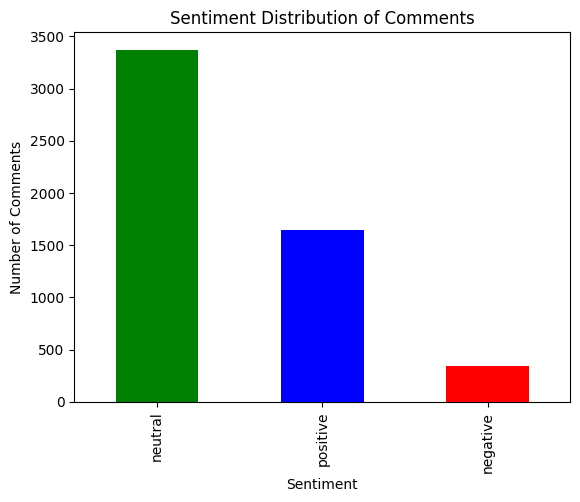

In [75]:
import matplotlib.pyplot as plt

# Count the number of comments for each sentiment label
sentiment_counts = comments_df['sentiment'].value_counts()
sentiment_counts.plot(kind='bar', color=['green', 'blue', 'red'])
plt.xlabel('Sentiment')
plt.ylabel('Number of Comments')
plt.title('Sentiment Distribution of Comments')
plt.show()


In [76]:
comments_df.head()

,post_id,commentUser,timestamp,comments,likes,clean_comments,tokens,polarity,sentiment,tfidf_keywords,preferences,emoji_present
0,1,wilsonjunior5055,2023-06-05 12:27:24+00:00,"I have a proposal for u, send me a DM please!",0.0,i have a proposal for u send me a dm please,"[proposal, u, send, dm, please]",0.2074,neutral,"[please, amazing, beautiful, clapping_hands, de]",[],[]
1,1,mariavmh,2023-06-04 16:46:40+00:00,Woaaaah,0.0,woaaaah,[woaaaah],-0.5351,negative,"[amazing, beautiful, clapping_hands, de, fire]",[],[]
2,1,mariavmh,2023-06-04 16:46:34+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...,0.0,smiling_face_with_hearteyessmiling_face_with_h...,[smiling_face_with_hearteyessmiling_face_with_...,-0.0151,neutral,"[amazing, beautiful, clapping_hands, de, fire]",[],[]
3,1,stylemesoftly_,2023-06-04 15:44:54+00:00,:red_heart:️:red_heart:️:red_heart:️,0.0,red_heartred_heartred_heart,[red_heartred_heartred_heart],-0.4655,negative,"[red_heartred_heartred_heart, amazing, beautif...",[],[]
4,1,jillviv,2023-06-04 15:06:03+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...,0.0,smiling_face_with_hearteyessmiling_face_with_h...,[smiling_face_with_hearteyessmiling_face_with_...,0.9696,positive,[smiling_face_with_hearteyessmiling_face_with_...,[],[]


In [77]:
processed_comments_df = comments_df.drop(columns=['comments','preferences','emoji_present'])
processed_comments_df.head()

,post_id,commentUser,timestamp,likes,clean_comments,tokens,polarity,sentiment,tfidf_keywords
0,1,wilsonjunior5055,2023-06-05 12:27:24+00:00,0.0,i have a proposal for u send me a dm please,"[proposal, u, send, dm, please]",0.2074,neutral,"[please, amazing, beautiful, clapping_hands, de]"
1,1,mariavmh,2023-06-04 16:46:40+00:00,0.0,woaaaah,[woaaaah],-0.5351,negative,"[amazing, beautiful, clapping_hands, de, fire]"
2,1,mariavmh,2023-06-04 16:46:34+00:00,0.0,smiling_face_with_hearteyessmiling_face_with_h...,[smiling_face_with_hearteyessmiling_face_with_...,-0.0151,neutral,"[amazing, beautiful, clapping_hands, de, fire]"
3,1,stylemesoftly_,2023-06-04 15:44:54+00:00,0.0,red_heartred_heartred_heart,[red_heartred_heartred_heart],-0.4655,negative,"[red_heartred_heartred_heart, amazing, beautif..."
4,1,jillviv,2023-06-04 15:06:03+00:00,0.0,smiling_face_with_hearteyessmiling_face_with_h...,[smiling_face_with_hearteyessmiling_face_with_...,0.9696,positive,[smiling_face_with_hearteyessmiling_face_with_...


In [78]:
#comments_df.to_csv('new_comments.csv', index=False)

In [79]:
#processed_comments_df = processed_comments_df.groupby("post_id").agg({
#    "polarity": "mean",  # Tính trung bình cảm xúc,
#    "tfidf_keywords": lambda x: ' '.join(x.dropna().astype(str))  # Nối các từ khóa lại thành 1 chuỗi
#
#}).reset_index()

In [80]:
processed_posts_df.rename(columns={"keywords_tfidf": "tfidf_keywords"}, inplace=True)

processed_posts_df.head()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_20928\4057846051.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  processed_posts_df.rename(columns={"keywords_tfidf": "tfidf_keywords"}, inplace=True)


,post_id,postUser,timestamp,likesCount,commentsCount,combined_keywords
0,1,maryleest,2023-06-02 16:34:43+00:00,32070,142,"[cannes, kilian, dress, 2023, kilianparis, kil..."
1,2,tinaabeysekara,2023-01-01 07:49:16+00:00,6565,86,"[2022, 2023, clock, struck, midnight, year, ev..."
2,3,maryleest,2023-05-29 18:57:51+00:00,28936,123,"[dress, jewelry, famous, stairs, photo, gustav..."
3,4,stephaniebroek,2023-03-07 19:30:42+00:00,4764,215,"[show, chanel, fashion, shoes, visualized, edi..."
4,5,maryleest,2023-05-23 21:11:12+00:00,13379,123,"[cannes, cannesfilmfestival, festival, got, wi..."


In [81]:
#Rename columns "tfidf_keywords"
processed_comments_df.rename(columns={"tfidf_keywords": "keywords_tfidf_comments"}, inplace=True)
processed_comments_df.head()

,post_id,commentUser,timestamp,likes,clean_comments,tokens,polarity,sentiment,keywords_tfidf_comments
0,1,wilsonjunior5055,2023-06-05 12:27:24+00:00,0.0,i have a proposal for u send me a dm please,"[proposal, u, send, dm, please]",0.2074,neutral,"[please, amazing, beautiful, clapping_hands, de]"
1,1,mariavmh,2023-06-04 16:46:40+00:00,0.0,woaaaah,[woaaaah],-0.5351,negative,"[amazing, beautiful, clapping_hands, de, fire]"
2,1,mariavmh,2023-06-04 16:46:34+00:00,0.0,smiling_face_with_hearteyessmiling_face_with_h...,[smiling_face_with_hearteyessmiling_face_with_...,-0.0151,neutral,"[amazing, beautiful, clapping_hands, de, fire]"
3,1,stylemesoftly_,2023-06-04 15:44:54+00:00,0.0,red_heartred_heartred_heart,[red_heartred_heartred_heart],-0.4655,negative,"[red_heartred_heartred_heart, amazing, beautif..."
4,1,jillviv,2023-06-04 15:06:03+00:00,0.0,smiling_face_with_hearteyessmiling_face_with_h...,[smiling_face_with_hearteyessmiling_face_with_...,0.9696,positive,[smiling_face_with_hearteyessmiling_face_with_...


In [82]:
df = pd.merge(processed_posts_df, processed_comments_df, on='post_id', how='left')
df.head()


,post_id,postUser,timestamp_x,likesCount,commentsCount,combined_keywords,commentUser,timestamp_y,likes,clean_comments,tokens,polarity,sentiment,keywords_tfidf_comments
0,1,maryleest,2023-06-02 16:34:43+00:00,32070,142,"[cannes, kilian, dress, 2023, kilianparis, kil...",wilsonjunior5055,2023-06-05 12:27:24+00:00,0.0,i have a proposal for u send me a dm please,"[proposal, u, send, dm, please]",0.2074,neutral,"[please, amazing, beautiful, clapping_hands, de]"
1,1,maryleest,2023-06-02 16:34:43+00:00,32070,142,"[cannes, kilian, dress, 2023, kilianparis, kil...",mariavmh,2023-06-04 16:46:40+00:00,0.0,woaaaah,[woaaaah],-0.5351,negative,"[amazing, beautiful, clapping_hands, de, fire]"
2,1,maryleest,2023-06-02 16:34:43+00:00,32070,142,"[cannes, kilian, dress, 2023, kilianparis, kil...",mariavmh,2023-06-04 16:46:34+00:00,0.0,smiling_face_with_hearteyessmiling_face_with_h...,[smiling_face_with_hearteyessmiling_face_with_...,-0.0151,neutral,"[amazing, beautiful, clapping_hands, de, fire]"
3,1,maryleest,2023-06-02 16:34:43+00:00,32070,142,"[cannes, kilian, dress, 2023, kilianparis, kil...",stylemesoftly_,2023-06-04 15:44:54+00:00,0.0,red_heartred_heartred_heart,[red_heartred_heartred_heart],-0.4655,negative,"[red_heartred_heartred_heart, amazing, beautif..."
4,1,maryleest,2023-06-02 16:34:43+00:00,32070,142,"[cannes, kilian, dress, 2023, kilianparis, kil...",jillviv,2023-06-04 15:06:03+00:00,0.0,smiling_face_with_hearteyessmiling_face_with_h...,[smiling_face_with_hearteyessmiling_face_with_...,0.9696,positive,[smiling_face_with_hearteyessmiling_face_with_...


In [83]:
final_df = df.copy()

final_df['keywords_posts'] = final_df.apply(lambda row: list(set(row['keywords_tfidf_posts'] + row['keywords_freq'] + row['keywords_weighted'])), axis=1)
final_df = final_df.drop(columns=['keywords_tfidf_posts', 'keywords_freq', 'keywords_weighted','clean_caption'])
# Rename columns "polarity" and "keywords_tfidf_comments"
final_df = final_df.rename(columns={"polarity": "score_segtiment", "keywords_tfidf_comments": "keywords_comments"})
final_df.head()

KeyError: 'keywords_tfidf_posts'

In [43]:
final_df.to_csv('final_df.csv', index=False)

In [44]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 827 entries, 0 to 826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   post_id            827 non-null    int64              
 1   postUser           827 non-null    object             
 2   timestamp          827 non-null    datetime64[ns, UTC]
 3   combined_tokens    827 non-null    object             
 4   likesCount         827 non-null    int64              
 5   commentsCount      827 non-null    int64              
 6   score_segtiment    755 non-null    float64            
 7   keywords_comments  756 non-null    object             
 8   keywords_posts     827 non-null    object             
dtypes: datetime64[ns, UTC](1), float64(1), int64(3), object(4)
memory usage: 58.3+ KB
